## Riff 1

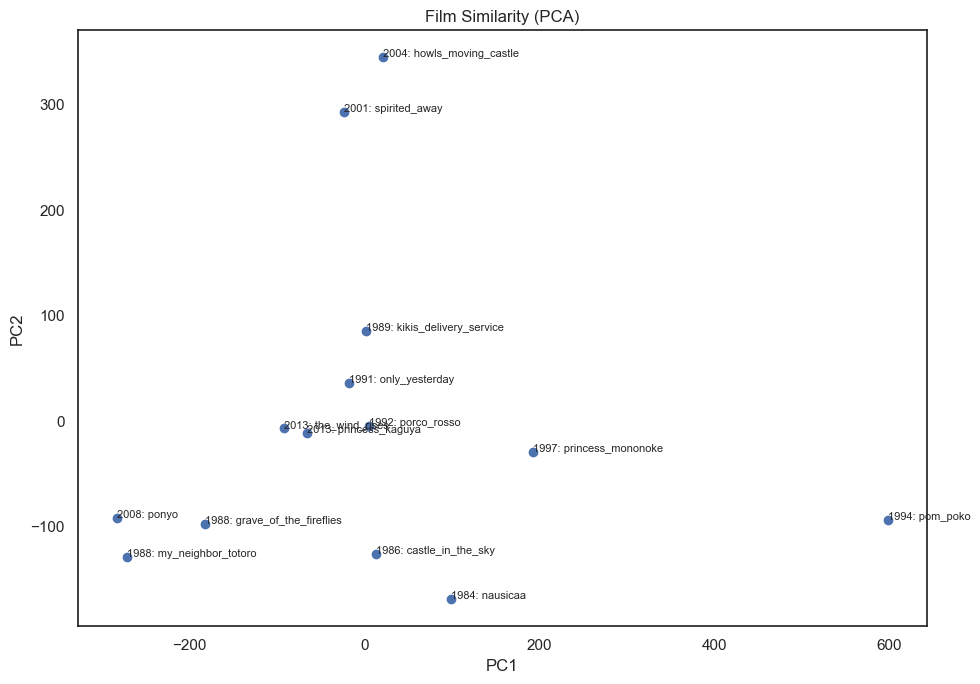

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

LIB = pd.read_csv("tables/LIB.csv")
CORPUS = pd.read_csv("tables/CORPUS.csv")

OHCO = ['film_name', 'chunk_num', 'sent_num', 'token_num']

CORPUS = CORPUS.set_index(OHCO).dropna()

BOW = CORPUS.groupby(['film_name', 'term_str']).term_str.count().to_frame('n')
DTM = BOW.n.unstack(fill_value=0)

if 'film_name' in LIB.columns and 'year' in LIB.columns:
    LIB['label'] = LIB['year'].astype(str) + ': ' + LIB['film_name']
    labels = LIB.set_index('film_name')['label']
else:
    labels = pd.Series(DTM.index, index=DTM.index)

labels = labels.reindex(DTM.index)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(DTM.values)

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

for i, label in enumerate(labels):
    plt.text(X_pca[i, 0], X_pca[i, 1], str(label), fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Film Similarity (PCA)")
plt.tight_layout()
plt.show()

## Riff 2

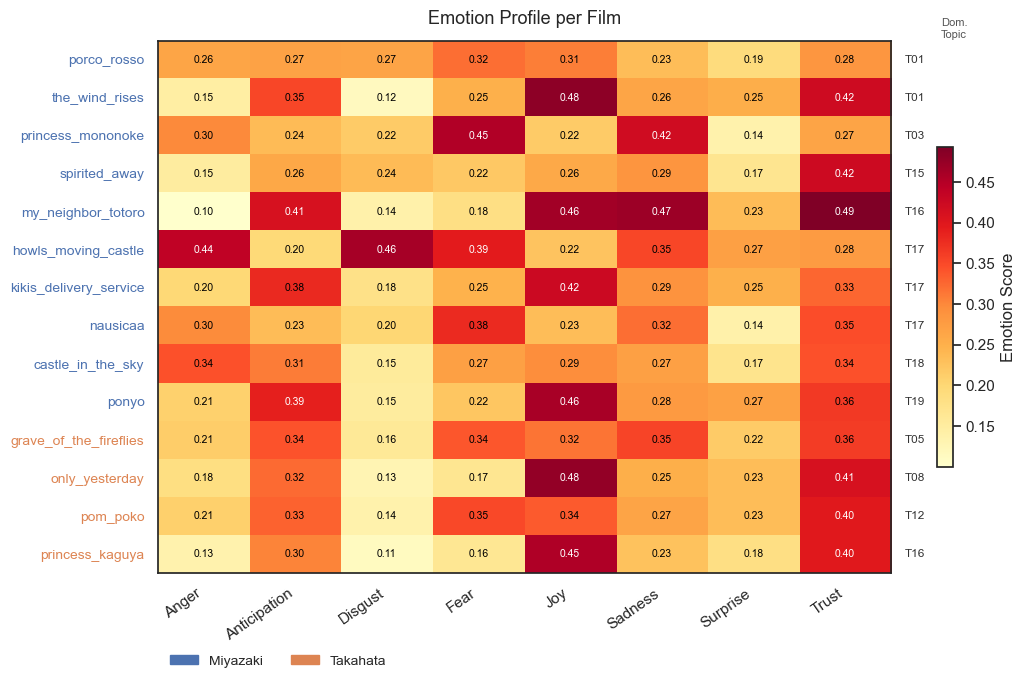

In [47]:
import matplotlib.patches as mpatches

THETA = pd.read_csv("tables/THETA.csv")
DOC_SENT = pd.read_csv("tables/DOC_SENT.csv")

EMOTION_COLS = ["anger", "anticipation", "disgust", "fear",
                "joy", "sadness", "surprise", "trust"]
TOPIC_COLS = [c for c in THETA.columns if c.startswith("T")]

DIR_COLORS = {"Miyazaki": "#4C72B0", "Takahata": "#DD8452"}
 
theta_mean = (
    THETA.groupby("film_name")[TOPIC_COLS].mean()
)
dominant_topic = theta_mean.idxmax(axis=1).rename("dominant_topic")
 
sent_df = (
    DOC_SENT.set_index("film_name")[EMOTION_COLS]
    .join(dominant_topic)
    .join(LIB.set_index("film_name")[["director"]])
)
sent_df = sent_df.sort_values(["director", "dominant_topic"])
 
heat_data = sent_df[EMOTION_COLS].astype(float)
 
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(heat_data.values, aspect="auto", cmap="YlOrRd",
               vmin=heat_data.values.min(), vmax=heat_data.values.max())
 
ax.set_xticks(range(len(EMOTION_COLS)))
ax.set_xticklabels([e.capitalize() for e in EMOTION_COLS],
                   rotation=35, ha="right", fontsize=11)
ax.set_yticks(range(len(sent_df)))
ax.set_yticklabels(sent_df.index, fontsize=10)
 
for row_i, (film, row) in enumerate(sent_df.iterrows()):
    for col_j, emotion in enumerate(EMOTION_COLS):
        val = heat_data.loc[film, emotion]
        ax.text(col_j, row_i, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color="black" if val < 0.38 else "white")
 
for tick, (film, row) in zip(ax.get_yticklabels(), sent_df.iterrows()):
    tick.set_color(DIR_COLORS[row["director"]])
 
for row_i, (film, row) in enumerate(sent_df.iterrows()):
    ax.text(len(EMOTION_COLS) - 0.35, row_i,
            row["dominant_topic"], va="center", fontsize=8.5, color="#333")
 
ax.text(len(EMOTION_COLS) + 0.05, -0.8, "Dom.\nTopic",
        va="center", fontsize=8, color="#555")
 
legend_handles = [
    mpatches.Patch(color=DIR_COLORS["Miyazaki"], label="Miyazaki"),
    mpatches.Patch(color=DIR_COLORS["Takahata"], label="Takahata"),
]
ax.legend(handles=legend_handles, loc="upper left",
          bbox_to_anchor=(0, -0.13), ncol=2, frameon=False, fontsize=10)
 
plt.colorbar(im, ax=ax, shrink=0.6, label="Emotion Score")
ax.set_title("Emotion Profile per Film",
             fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## Riff 3

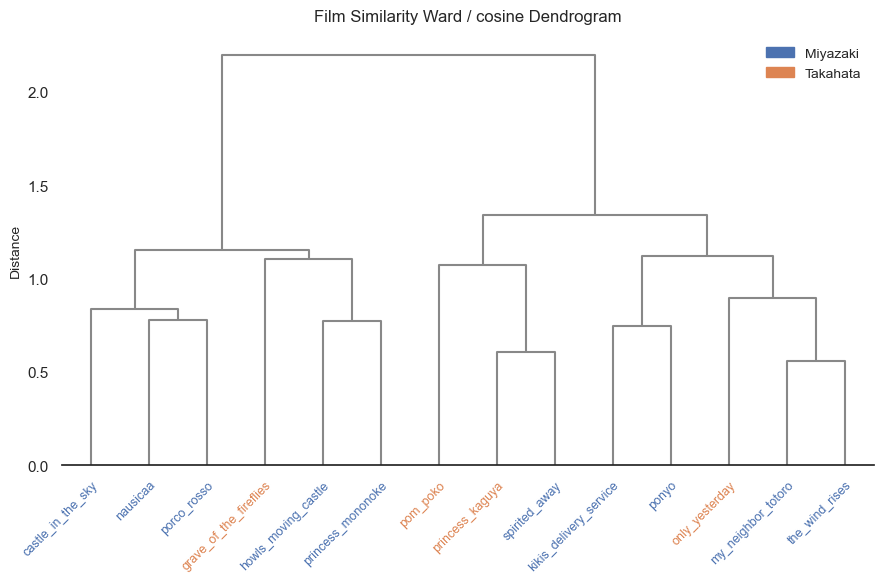

In [57]:
from scipy.cluster.hierarchy import dendrogram, linkage

sent_feat = DOC_SENT.set_index("film_name")[EMOTION_COLS + ["sentiment"]]
topic_feat = theta_mean
 
combined = sent_feat.join(topic_feat)
 
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(combined),
    index=combined.index,
    columns=combined.columns,
)
 
Z = linkage(pdist(X, metric="cosine"), method="ward")
 
film_order_idx = dendrogram(Z, no_plot=True)["leaves"]
film_order = [X.index[i] for i in film_order_idx]
leaf_colors = [
    DIR_COLORS[LIB.set_index("film_name").loc[f, "director"]]
    for f in film_order
]
 
fig, ax = plt.subplots(figsize=(9, 6))
ddata = dendrogram(Z, ax=ax, orientation="top",
                   labels=list(X.index),
                   color_threshold=0, above_threshold_color="#888",
                   leaf_font_size=9, leaf_rotation=45)

plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
 
for lbl, color in zip(ax.get_xticklabels(), leaf_colors):
    lbl.set_color(color)
 
legend_handles = [
    mpatches.Patch(color=DIR_COLORS["Miyazaki"], label="Miyazaki"),
    mpatches.Patch(color=DIR_COLORS["Takahata"], label="Takahata"),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=False, fontsize=10)
ax.set_title("Film Similarity Ward / cosine Dendrogram",
             fontsize=12, pad=10)
ax.set_ylabel("Distance", fontsize=10)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()